In [3]:
from collections import defaultdict
from typing import Any

import dnnlpy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as utils
import torchvision.datasets as datasets
import torchvision.transforms.v2 as v2
from numpy.random.mtrand import logistic
from torch import Tensor
from torch.utils.hipify.hipify_python import find_bracket_group

torch.manual_seed(42)
dnnlpy.set_matplotlib_format('svg')
print("PyTorch  version: ", torch.__version__)


PyTorch  version:  2.13.0+cpu


In [7]:
"""
从Numpy版本回顾模型结构
"""


class MLP(nn.Module):
    def __init__(self, input_dim: int = 784, hidden_dim: int = 256, num_classes: int = 10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)

        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


model = MLP(input_dim=784, hidden_dim=256, num_classes=10)
x = torch.randn(32, 1, 28, 28)
logits = model(x)

print("logits  shape:", logits.shape)

# 计算损失

loss_fn = nn.CrossEntropyLoss()
y = torch.randint(10, size=(32,))
loss = loss_fn(logits, y)

print("loss:", loss.item())


logits  shape: torch.Size([32, 10])
loss: 2.315216064453125


In [10]:
"""
PyTorch 自动完成反向传播
"""

model = MLP()
loss_fn = nn.CrossEntropyLoss()

x = torch.randn(32, 1, 28, 28)
y = torch.randint(10, size=(32,))

logits = model(x)
loss = loss_fn(logits, y)
loss.backward()
print("The shape of fist layer:", model.net[1].weight.grad.shape)


The shape of fist layer: torch.Size([256, 784])


In [11]:
"""
用optimizer 更新参数
    optimizer.zero_grad(): 清空上一轮的梯度
    logits = model(x)  做前向传播
    loss = loss_fn(logits, y) : 计算损失
    optimizer.step()  根据梯度更新参数
"""

model = MLP(input_dim=784, hidden_dim=256, num_classes=10)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 一次训练的步骤
optimizer.zero_grad()
logits = model(x)
loss = loss_fn(logits, y)
loss.backward()
optimizer.step()


In [16]:
"""
 准备MNIST数据集
"""
root = dnnlpy.get_data_root()
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_ds = datasets.MNIST(root, train=True, transform=transform, download=True)
test_ds = datasets.MNIST(root, train=False, transform=transform, download=True)

train_dl = utils.DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl = utils.DataLoader(test_ds, batch_size=256, shuffle=True)

In [20]:
"""
训练一个PyTorch  MLP
"""
device = dnnlpy.get_default_device()
print("Using device:", device)

model = MLP(input_dim=784, hidden_dim=256, num_classes=10).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
history = defaultdict(list)

# 训练
num_epochs = 10

for epoch in range(1, num_epochs + 1):
    model.train()

    train_loss = 0
    correct_simple = 0

    for X, y in train_dl:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()
        correct_simple += (logits.argmax(dim=1) == y).sum().item()
    avg_train_loss = train_loss / len(train_dl)
    avg_train_acc = correct_simple / len(train_ds)
    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(avg_train_acc)

    model.eval()
    test_loss = 0.0
    correct_simple = 0

    for X, y in test_dl:
        X.to(device)
        y.to(device)

        with torch.inference_mode():
            logits = model(X)
            loss = loss_fn(logits, y)

        test_loss += loss.item()
        correct_simple += (logits.argmax(dim=1) == y).sum().item()
    avg_test_loss = test_loss / len(test_dl)
    avg_test_acc = correct_simple / len(test_ds)
    history["test_loss"].append(avg_test_loss)
    history["test_acc"].append(avg_test_acc)

    n = len(str(num_epochs))
    print(f"Epoch [{epoch:{n}d}/{num_epochs:{n}d}]"
          f'|loss:{avg_train_loss:.4f}'
          f'|acc:{avg_train_acc:.4f}'
          f'|test_loss:{avg_test_loss:.4f}'
          f'|test_acc:{avg_test_acc:.4f}')


Using device: cpu
Epoch [ 1/10]|loss:0.5688|acc:0.8574|test_loss:0.3019|test_acc:0.9138
Epoch [ 2/10]|loss:0.2869|acc:0.9185|test_loss:0.2491|test_acc:0.9316
Epoch [ 3/10]|loss:0.2347|acc:0.9331|test_loss:0.2107|test_acc:0.9391
Epoch [ 4/10]|loss:0.1987|acc:0.9439|test_loss:0.1760|test_acc:0.9476
Epoch [ 5/10]|loss:0.1714|acc:0.9521|test_loss:0.1622|test_acc:0.9530
Epoch [ 6/10]|loss:0.1502|acc:0.9575|test_loss:0.1402|test_acc:0.9587
Epoch [ 7/10]|loss:0.1339|acc:0.9618|test_loss:0.1293|test_acc:0.9631
Epoch [ 8/10]|loss:0.1202|acc:0.9666|test_loss:0.1155|test_acc:0.9647
Epoch [ 9/10]|loss:0.1091|acc:0.9697|test_loss:0.1135|test_acc:0.9663
Epoch [10/10]|loss:0.0999|acc:0.9722|test_loss:0.1044|test_acc:0.9688


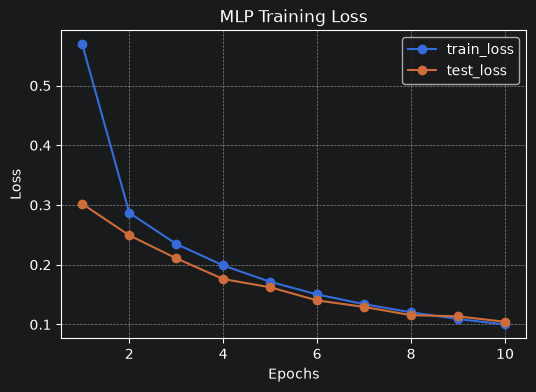

In [21]:
"""
可视化训练过程
"""
fig = plt.figure(1,figsize=(6,4))
ax =  fig.add_subplot(1,1,1)
xticks = torch.arange(1,num_epochs+1)
ax.plot(xticks, history["train_loss"],marker='o')
ax.plot(xticks, history["test_loss"],marker='o')
ax.grid(linestyle='--',alpha=0.7)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')

ax.legend(['train_loss','test_loss'])
ax.set_title("MLP Training Loss")
plt.show()

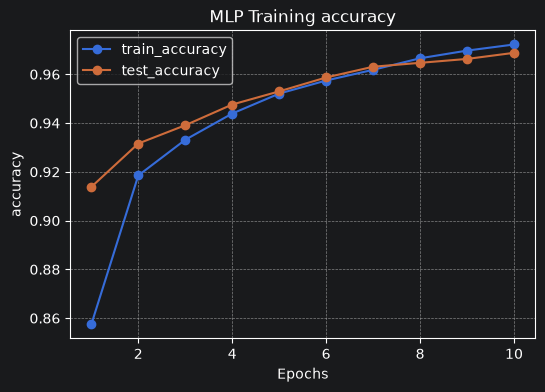

In [22]:
fig = plt.figure(1,figsize=(6,4))
ax =  fig.add_subplot(1,1,1)
xticks = torch.arange(1,num_epochs+1)
ax.plot(xticks, history["train_acc"],marker='o')
ax.plot(xticks, history["test_acc"],marker='o')
ax.grid(linestyle='--',alpha=0.7)
ax.set_xlabel('Epochs')
ax.set_ylabel('accuracy')

ax.legend(['train_accuracy','test_accuracy'])
ax.set_title("MLP Training accuracy")
plt.show()